In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import linear_model

In [2]:
df=pd.read_csv("D:\data  science\pandas\car_sales_data.csv")

In [3]:
df

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


<Axes: >

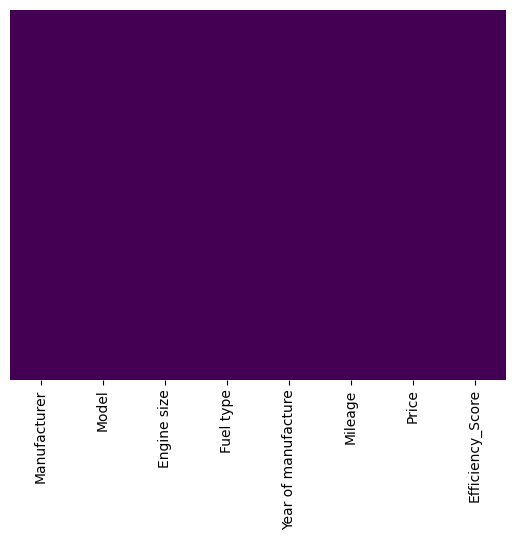

In [59]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [4]:
df.groupby('Manufacturer')['Price'].mean()

Manufacturer
BMW        24429.459215
Ford       10672.288723
Porsche    29103.764661
Toyota     14340.362275
VW         10363.139274
Name: Price, dtype: float64

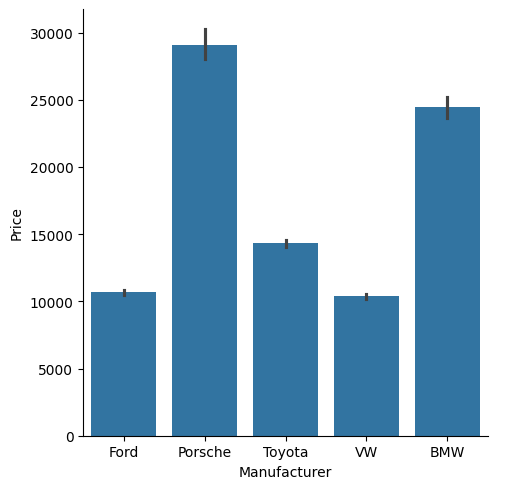

In [5]:
sns.catplot(x='Manufacturer', y='Price', kind='bar', data=df) 

<function matplotlib.pyplot.show(close=None, block=None)>

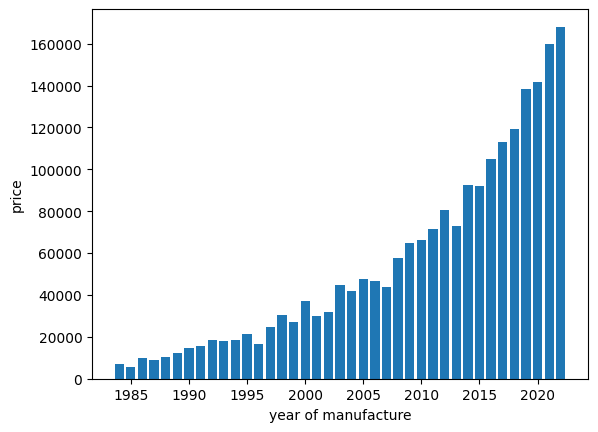

In [6]:
x=df["Year of manufacture"]
y=df["Price"]
plt.bar(x,y)
plt.xlabel("year of manufacture")
plt.ylabel("price")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

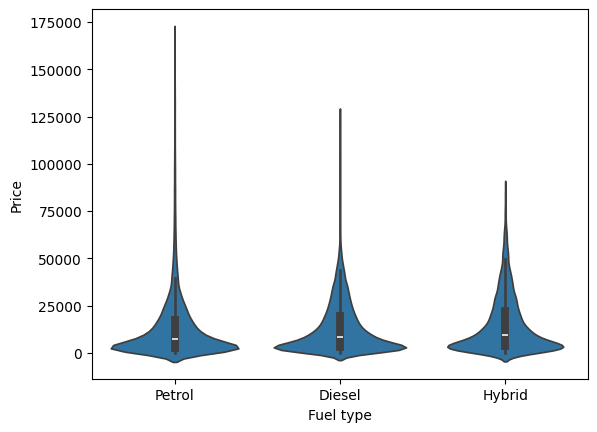

In [7]:
sns.violinplot(
   x=df["Fuel type"],
   y=df["Price"]
)
plt.show

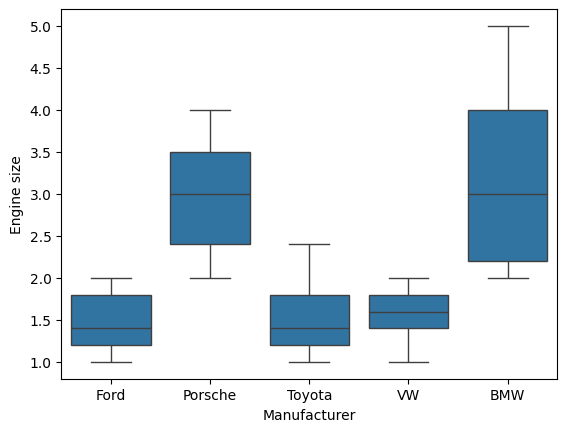

In [8]:
sns.boxplot(x="Manufacturer", y="Engine size",data=df)
plt.show()


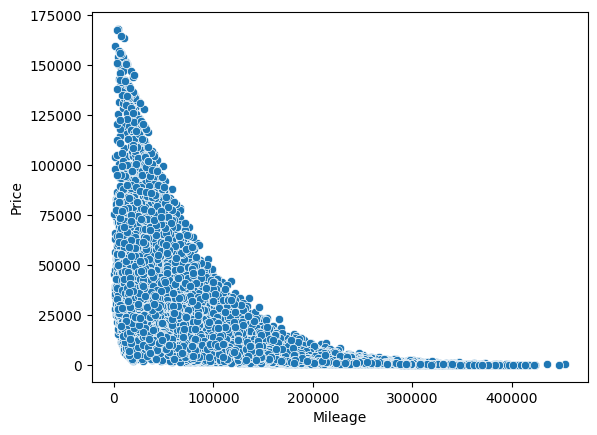

In [9]:
sns.scatterplot(x="Mileage", y="Price",data=df)
plt.show()


In [10]:
df['Efficiency_Score']=10/df['Engine size']
df.loc[df['Fuel type'] == 'Hybrid','Efficiency_Score']*=2.0
df.loc[df['Fuel type'] == 'Petrol','Efficiency_Score']*=1.3
df.loc[df['Fuel type'] == 'Diesel','Efficiency_Score']*=1.0

In [11]:
df

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Efficiency_Score
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,13.000000
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,3.250000
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,6.250000
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,11.111111
4,VW,Polo,1.0,Petrol,2006,127869,4101,13.000000
...,...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006,2.600000
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430,11.111111
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852,6.250000
49998,Ford,Focus,1.0,Diesel,2016,26468,23630,10.000000


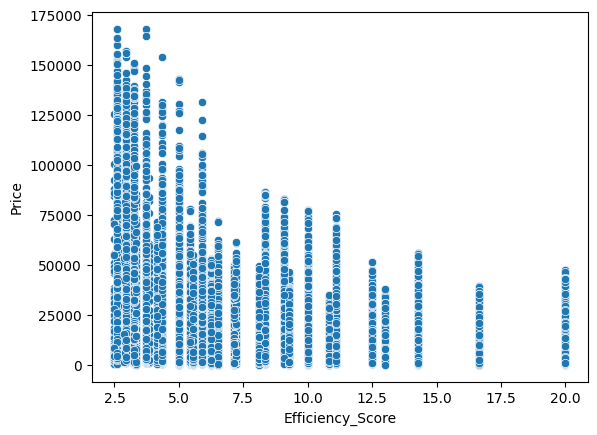

In [12]:
sns.scatterplot(x='Efficiency_Score',y='Price',data=df)
plt.show()

===============================================================================




lets predict the price of the car with respect to the year of manufacture





============================================================================

In [14]:
yeardf=df[["Year of manufacture","Price"]]

In [15]:
yeardf

,Year of manufacture,Price
0,2002,3074
1,2016,49704
2,2014,24072
3,1988,1705
4,2006,4101
...,...,...
49995,2018,113006
49996,2003,9430
49997,2022,49852
49998,2016,23630


<function matplotlib.pyplot.show(close=None, block=None)>

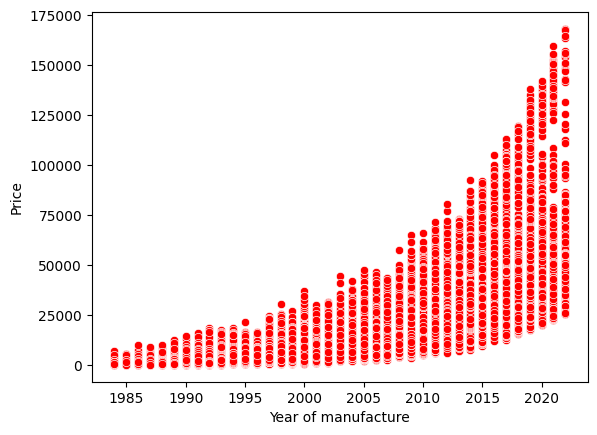

In [16]:
sns.scatterplot(x="Year of manufacture",y="Price",data=df,color='red')
plt.show

In [17]:
df20=yeardf.groupby('Year of manufacture')['Price'].mean().reset_index()

In [18]:
df20

,Year of manufacture,Price
0,1984,998.376712
1,1985,1102.658537
2,1986,1201.615561
3,1987,1302.869421
4,1988,1420.259563
5,1989,1707.623913
6,1990,1875.973850
7,1991,2057.704314
8,1992,2284.163650
9,1993,2555.622089


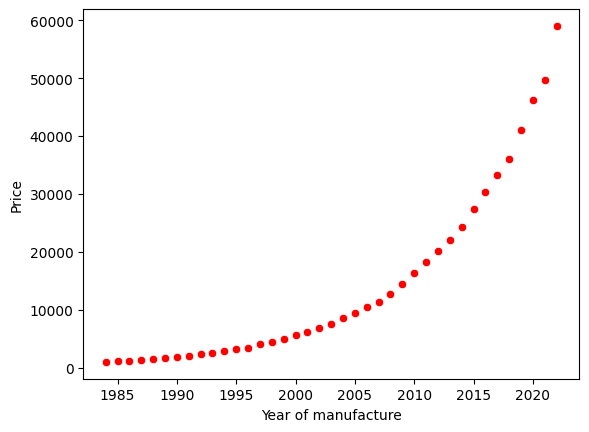

In [19]:
sns.scatterplot(x='Year of manufacture',y="Price",data=df20,color='red')
plt.show()

In [20]:
reg=linear_model.LinearRegression()
reg.fit(df20[['Year of manufacture']],df20.Price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
reg.predict(pd.DataFrame({'Year of manufacture': [1998]}))


array([8239.80544173])

In [22]:
reg.predict(pd.DataFrame({'Year of manufacture': [2025]}))

array([40864.56298964])

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = reg.predict(df20[['Year of manufacture']])
y_true = df20['Price']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 5600.76
MSE: 47070533.76
RMSE: 6860.80
R² Score: 0.80


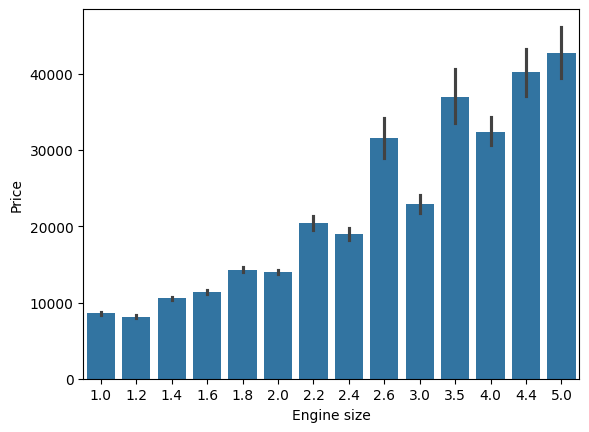

In [24]:
sns.barplot(x="Engine size", y="Price",data=df)
plt.show()

In [25]:
dfeng=df.groupby("Engine size")["Price"].mean().reset_index()

In [26]:
dfeng

,Engine size,Price
0,1.0,8601.266278
1,1.2,8129.331862
2,1.4,10583.946223
3,1.6,11391.441096
4,1.8,14287.910694
5,2.0,13987.663478
6,2.2,20460.541120
7,2.4,18928.516497
8,2.6,31551.276786
9,3.0,22946.529971


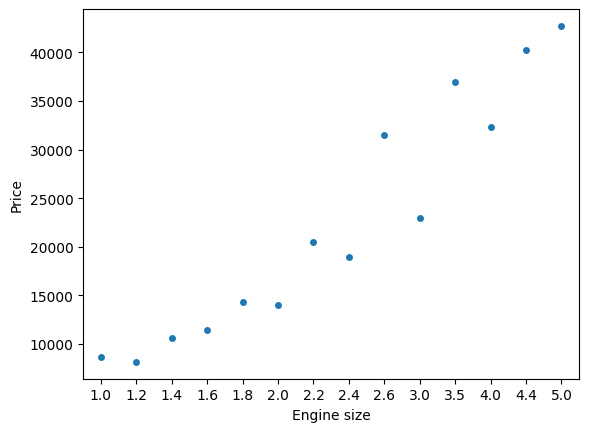

In [27]:
sns.stripplot(x="Engine size",y="Price",data=dfeng)
plt.show()

In [28]:
regg=linear_model.LinearRegression()
regg.fit(dfeng[["Engine size"]],dfeng.Price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
regg.predict(pd.DataFrame({"Engine size": [1.9]}))

array([16004.07671511])